# K-Means — Segmentação de Clientes

## 0. Bibliotecas

In [1]:
if (!requireNamespace('dplyr',       quietly=TRUE)) install.packages('dplyr')
if (!requireNamespace('tidyr',       quietly=TRUE)) install.packages('tidyr')
if (!requireNamespace('ggplot2',     quietly=TRUE)) install.packages('ggplot2')
if (!requireNamespace('factoextra',  quietly=TRUE)) install.packages('factoextra')
if (!requireNamespace('cluster',     quietly=TRUE)) install.packages('cluster')

library(dplyr)
library(tidyr)
library(ggplot2)
library(factoextra)
library(cluster)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.

## 1. Carregar o dataset completo

In [2]:
# Carregamento do dataset com todas as features disponíveis
df_raw <- read.csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vRUH7DkszbT0b0_QcnuAPLnhyEG94NAo9tzatYptl2F6M4y1HZLI4q86WhZpaL6HpPczwOsvP5sHEfq/pub?output=csv")

cat('Dimensão:', nrow(df_raw), 'linhas x', ncol(df_raw), 'colunas\n')
cat('Colunas disponíveis:\n')
print(names(df_raw))

Dimensão: 23658 linhas x 19 colunas
Colunas disponíveis:
 [1] "customer_unique_id"         "recency_days"              
 [3] "total_orders"               "total_spent"               
 [5] "review_insatisfeito"        "review_neutro"             
 [7] "review_satisfeito"          "avg_delivery_delay_days"   
 [9] "avg_items_per_order"        "cat_cama_mesa_banho"       
[11] "cat_esporte_lazer"          "cat_beleza_saude"          
[13] "cat_moveis_decoracao"       "cat_informatica_acessorios"
[15] "cat_outros"                 "state_sp"                  
[17] "state_rj"                   "state_mg"                  
[19] "state_outros"              


## 2. SELECÇÃO DE FEATURES (alterar aqui em cada iteração)
Nota: Editar o vector `features_usar` com os nomes das colunas pretendidas.
As colunas `customer_unique_id` e `target_repurchase` são excluídas automaticamente.

In [3]:
# ---------------------------------------------------------------
# DEFINIR AS FEATURES A USAR NESTA ITERAÇÃO
# ---------------------------------------------------------------
features_usar <- c(
  'recency_days',
  'total_spent',
  'total_orders',
  'avg_delivery_delay_days'
)

# Rótulo desta iteração
rotulo_iteracao <- "Iteração 3 — RFM + Delivery delay"


# ---------------------------------------------------------------
# NÃO ALTERAR A PARTIR DAQUI
# ---------------------------------------------------------------

# Separar features numéricas e categóricas
features_num  <- features_usar[sapply(df_raw[features_usar], is.numeric)]
features_cat  <- features_usar[sapply(df_raw[features_usar], function(x) is.character(x) | is.factor(x))]

cat('Features numéricas:', paste(features_num, collapse=', '), '\n')
cat('Features categóricas:', paste(features_cat, collapse=', '), '\n')

# Extrair e imputar numéricas
df_num <- df_raw[features_num]
df_num <- as.data.frame(lapply(df_num, function(x)
  ifelse(is.na(x), median(x, na.rm=TRUE), x)))

# One-Hot Encoding para categóricas (se existirem)
if (length(features_cat) > 0) {
  df_cat <- df_raw[features_cat]
  df_cat <- as.data.frame(lapply(df_cat, as.factor))
  ohe     <- model.matrix(~ . - 1, data = df_cat)
  features_all <- cbind(df_num, ohe)
} else {
  features_all <- df_num
}

# Normalização
features_scaled <- scale(features_all)

cat('\nTotal de features após OHE:', ncol(features_scaled), '\n')
cat('NAs nas features numéricas:', sum(is.na(df_num)), '\n')

Features numéricas: recency_days, total_spent, total_orders, avg_delivery_delay_days 
Features categóricas:  

Total de features após OHE: 4 
NAs nas features numéricas: 0 


## 3. Método do Cotovelo - Escolha do K

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”


K recomendado pelo método do cotovelo: 3 


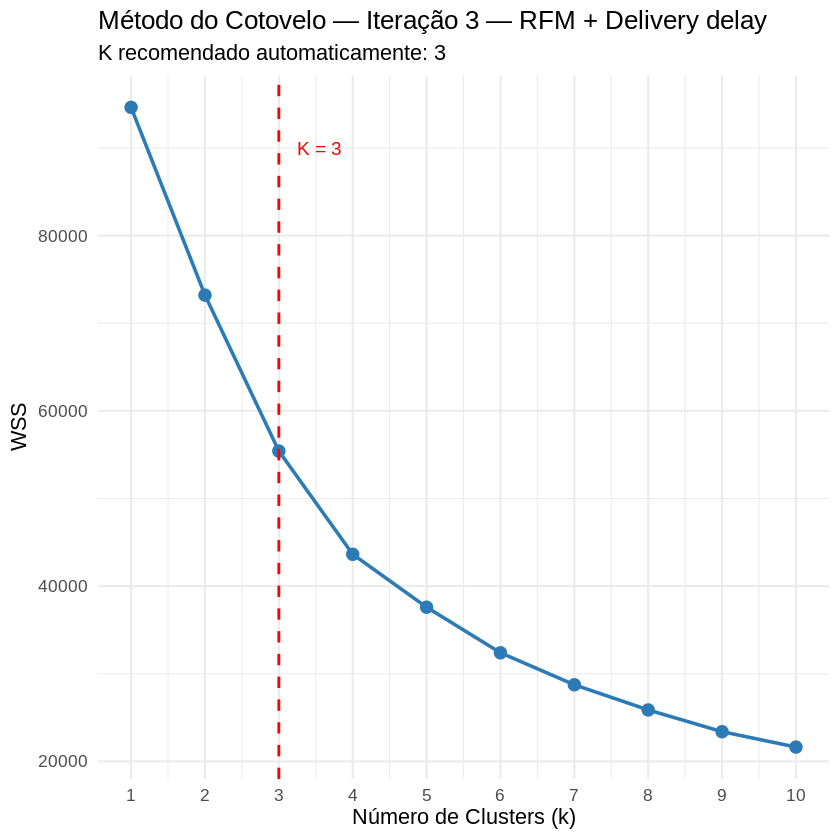

In [4]:
set.seed(42)
wss <- sapply(1:10, function(k)
  kmeans(features_scaled, centers=k, nstart=25, iter.max=100)$tot.withinss)

# Detecção automática do cotovelo (método das diferenças de 2ª ordem)
diffs1 <- diff(wss)        # 1ª diferença: declive entre pontos consecutivos
diffs2 <- diff(diffs1)     # 2ª diferença: variação do declive (o "joelho")
k_recomendado <- which.max(diffs2) + 1  # pico da 2ª diferença = cotovelo

cat('K recomendado pelo método do cotovelo:', k_recomendado, '\n')

ggplot(data.frame(k=1:10, wss=wss), aes(x=k, y=wss)) +
  geom_line(colour='#2C7BB6', linewidth=1) +
  geom_point(colour='#2C7BB6', size=3) +
  geom_vline(xintercept=k_recomendado, linetype='dashed',
             colour='red', linewidth=0.8) +
  annotate('text', x=k_recomendado + 0.25, y=max(wss)*0.95,
           label=paste('K =', k_recomendado),
           colour='red', size=4, hjust=0) +
  scale_x_continuous(breaks=1:10) +
  labs(
    title    = paste('Método do Cotovelo —', rotulo_iteracao),
    subtitle = paste('K recomendado automaticamente:', k_recomendado),
    x = 'Número de Clusters (k)', y = 'WSS'
  ) +
  theme_minimal(base_size=13)

## 4. Silhouette - Validação do K

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”


K recomendado pelo Silhouette: 2 
Silhouette score: 0.699 


Warning message:
“did not converge in 10 iterations”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“did not converge in 10 iterations”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”


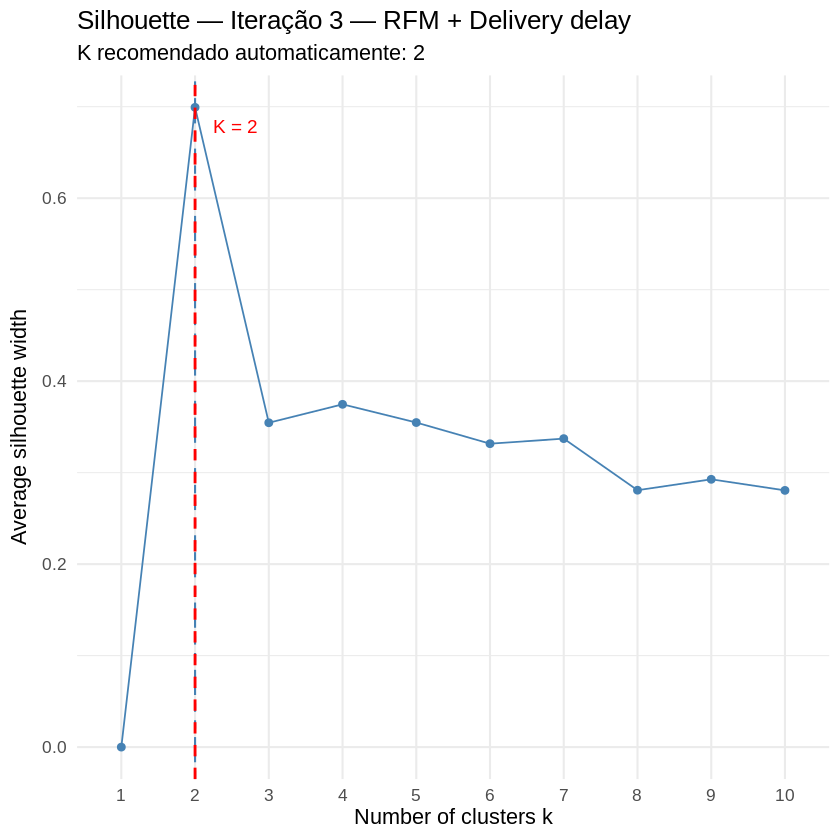

In [5]:
# Calcular silhouette para cada k e identificar o melhor
sil_scores <- sapply(2:10, function(k) {
  km  <- kmeans(features_scaled, centers=k, nstart=25, iter.max=100)
  sil <- silhouette(km$cluster, dist(features_scaled, method='euclidean'))
  mean(sil[, 3])
})

k_sil_recomendado <- which.max(sil_scores) + 1  # +1 porque começámos em k=2

cat('K recomendado pelo Silhouette:', k_sil_recomendado, '\n')
cat('Silhouette score:', round(max(sil_scores), 3), '\n')

fviz_nbclust(features_scaled, kmeans,
             method='silhouette', k.max=10, nstart=25) +
  geom_vline(xintercept=k_sil_recomendado, linetype='dashed',
             colour='red', linewidth=0.8) +
  annotate('text', x=k_sil_recomendado + 0.25, y=max(sil_scores)*0.97,
           label=paste('K =', k_sil_recomendado),
           colour='red', size=4, hjust=0) +
  labs(
    title    = paste('Silhouette —', rotulo_iteracao),
    subtitle = paste('K recomendado automaticamente:', k_sil_recomendado)
  ) +
  theme_minimal(base_size=13)

## 5. Correr o K-Means
> Nota: Ajustar `k_optimo` com base no cotovelo e silhouette acima.

In [6]:
# AJUSTAR após ver cotovelo e silhouette
k_optimo <- 3

set.seed(42)
modelo <- kmeans(features_scaled, centers=k_optimo, nstart=25, iter.max=100)

cat('==== K-Means —', rotulo_iteracao, '====\n')
cat('Tamanho dos clusters:\n'); print(modelo$size)
cat('Distribuição (%):\n')
print(round(modelo$size / sum(modelo$size) * 100, 1))
cat('BSS/TSS (variância explicada):',
    round(modelo$betweenss / modelo$totss * 100, 1), '%\n')

# Mapear clusters ao dataset original
df_resultado <- df_raw %>%
  mutate(cluster = as.factor(modelo$cluster))

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1182900)”


==== K-Means — Iteração 3 — RFM + Delivery delay ====
Tamanho dos clusters:
[1]   652 13332  9674
Distribuição (%):
[1]  2.8 56.4 40.9
BSS/TSS (variância explicada): 41.4 %


## 6. Perfil dos clusters

In [7]:
perfil_clusters <- df_resultado %>%
  group_by(cluster) %>%
  summarise(
    n_clientes = n(),
    pct        = round(n() / nrow(df_resultado) * 100, 1),
    across(all_of(features_num), ~round(mean(.x, na.rm=TRUE), 2),
           .names = 'media_{.col}'),
    .groups = 'drop'
  )

cat('==== PERFIL DOS CLUSTERS —', rotulo_iteracao, '====\n')
print(perfil_clusters)

==== PERFIL DOS CLUSTERS — Iteração 3 — RFM + Delivery delay ====
# A tibble: 3 × 7
  cluster n_clientes   pct media_recency_days media_total_spent
  <fct>        <int> <dbl>              <dbl>             <dbl>
1 1              652   2.8               96.2              324.
2 2            13332  56.4               67.1              151.
3 3             9674  40.9              180.               170.
# ℹ 2 more variables: media_total_orders <dbl>,
#   media_avg_delivery_delay_days <dbl>


## 7. Gráfico de linhas dos centróides (valores normalizados)

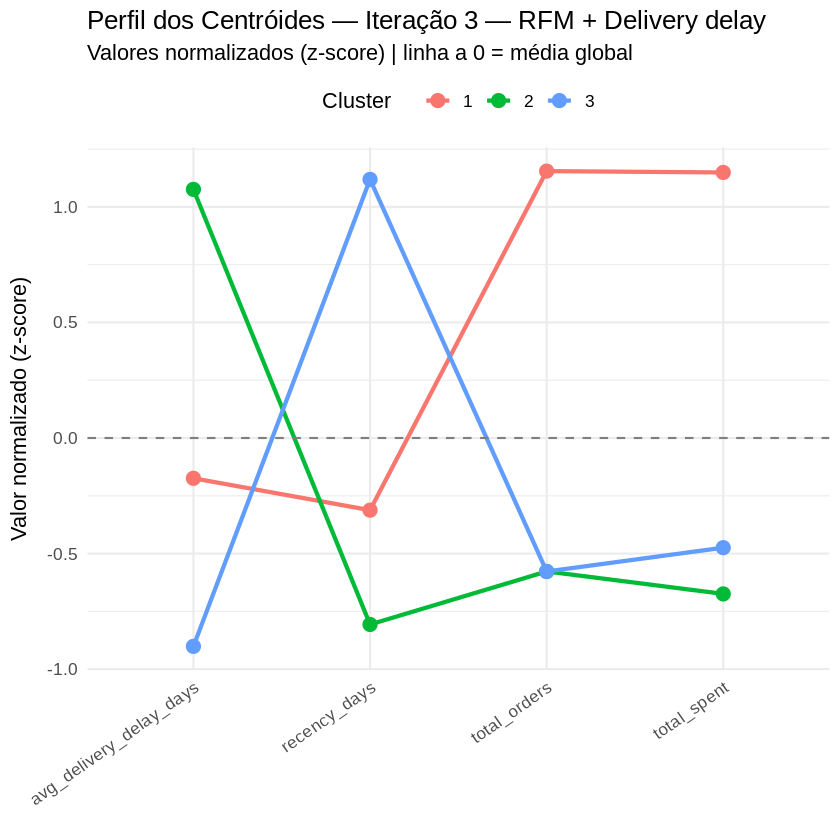

In [8]:
# Normalizar os valores médios do perfil (z-score entre clusters)
colunas_media <- paste0('media_', features_num)

perfil_norm <- perfil_clusters %>%
  select(cluster, all_of(colunas_media)) %>%
  mutate(across(all_of(colunas_media), ~scale(.x)[,1])) %>%
  pivot_longer(
    cols      = all_of(colunas_media),
    names_to  = 'feature',
    values_to = 'valor_norm'
  ) %>%
  mutate(feature = gsub('media_', '', feature))

ggplot(perfil_norm, aes(x=feature, y=valor_norm,
                        group=cluster, colour=cluster)) +
  geom_line(linewidth=1.2) +
  geom_point(size=3.5) +
  geom_hline(yintercept=0, linetype='dashed',
             colour='grey50', linewidth=0.6) +
  labs(
    title    = paste('Perfil dos Centróides —', rotulo_iteracao),
    subtitle = 'Valores normalizados (z-score) | linha a 0 = média global',
    x=NULL, y='Valor normalizado (z-score)', colour='Cluster'
  ) +
  theme_minimal(base_size=13) +
  theme(
    axis.text.x     = element_text(angle=35, hjust=1),
    legend.position = 'top'
  )

## 8. Distribuição de clientes por cluster

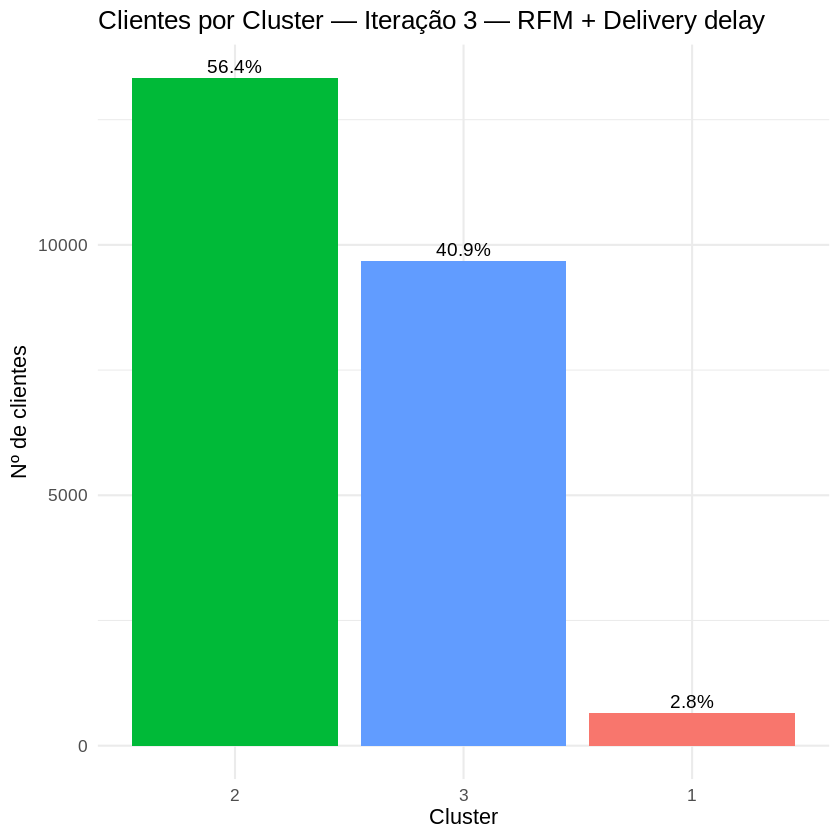

In [9]:
ggplot(perfil_clusters,
       aes(x=reorder(cluster, -n_clientes), y=n_clientes, fill=cluster)) +
  geom_col(show.legend=FALSE) +
  geom_text(aes(label=paste0(pct, '%')), vjust=-0.4, size=4) +
  labs(
    title    = paste('Clientes por Cluster —', rotulo_iteracao),
    x='Cluster', y='Nº de clientes'
  ) +
  theme_minimal(base_size=13)

## 9. Silhouette global

In [10]:
# Silhouette global
dist_matrix   <- dist(features_scaled, method='euclidean')
sil_resultado <- silhouette(modelo$cluster, dist_matrix)
sil_global    <- round(mean(sil_resultado[,3]), 3)
cat('Silhouette médio global:', sil_global, '\n')

Silhouette médio global: 0.355 
